In [90]:
import pandas as pd
import numpy as np

df = pd.read_csv("gym_members_exercise_tracking.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [92]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [93]:
def assign_plan(row):
    if row["Workout_Type"] == "HIIT":
        return "lose_fat"
    elif row["Workout_Type"] == "Strength":
        return "build_muscle"
    elif row["Workout_Type"] == "Cardio":
        return "endurance"
    elif row["Workout_Type"] == "Yoga":
        return "general_fitness"
    else:
        return "general_fitness"

df["recommended_plan"] = df.apply(assign_plan, axis=1)
df["recommended_plan"].value_counts()

recommended_plan
build_muscle       258
endurance          255
general_fitness    239
lose_fat           221
Name: count, dtype: int64

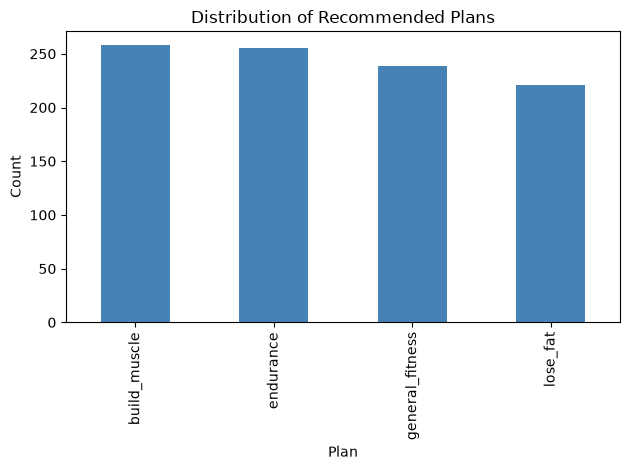

In [94]:
import matplotlib.pyplot as plt

df["recommended_plan"].value_counts().plot(kind="bar", color = "steelblue")
plt.title("Distribution of Recommended Plans")
plt.xlabel("Plan")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [95]:
df = df.drop(columns=["Max_BPM", "Avg_BPM", "Resting_BPM", "Water_Intake (liters)", "Workout_Type"])

df.head()

,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Fat_Percentage,Workout_Frequency (days/week),Experience_Level,BMI,recommended_plan
0,56,Male,88.3,1.71,1.69,1313.0,12.6,4,3,30.20,general_fitness
1,46,Female,74.9,1.53,1.30,883.0,33.9,4,2,32.00,lose_fat
2,32,Female,68.1,1.66,1.11,677.0,33.4,4,2,24.71,endurance
3,25,Male,53.2,1.70,0.59,532.0,28.8,3,1,18.41,build_muscle
4,38,Male,46.1,1.79,0.64,556.0,29.2,3,1,14.39,build_muscle


In [96]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

df.head()

,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Fat_Percentage,Workout_Frequency (days/week),Experience_Level,BMI,recommended_plan
0,56,0,88.3,1.71,1.69,1313.0,12.6,4,3,30.20,general_fitness
1,46,1,74.9,1.53,1.30,883.0,33.9,4,2,32.00,lose_fat
2,32,1,68.1,1.66,1.11,677.0,33.4,4,2,24.71,endurance
3,25,0,53.2,1.70,0.59,532.0,28.8,3,1,18.41,build_muscle
4,38,0,46.1,1.79,0.64,556.0,29.2,3,1,14.39,build_muscle


In [97]:
X = df.drop(columns = ["recommended_plan"])
y = df["recommended_plan"]


print(X.shape)
print(y.shape)

(973, 10)
(973,)


In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (778, 10)
Test set: (195, 10)


In [99]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train_encoded)

print("Model trained successfully")

Model trained successfully


In [100]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print("\n", classification_report(y_test_encoded, y_pred, target_names=le.classes_))

Accuracy: 18.97%

                  precision    recall  f1-score   support

   build_muscle       0.18      0.19      0.18        47
      endurance       0.18      0.24      0.20        46
general_fitness       0.22      0.13      0.17        60
       lose_fat       0.20      0.21      0.20        42

       accuracy                           0.19       195
      macro avg       0.19      0.19      0.19       195
   weighted avg       0.19      0.19      0.19       195



The Gym Members dataset didn't have labeled recommendations as a target variable. Engineering labels from Workout_Type then dropping it left no real signal for the model to learn from, leading to 19% accuracy. I will now generate synthetic data where the features are designed to preduct the target by construction, matching exactly what GetFit collects during onboarding.

In [101]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

ages = np.random.randint(18, 61, n)
genders = np.random.choice(["Male", "Female"], n)
heights = np.round(np.random.uniform(1.50, 2.00, n), 2)
weights = np.round(np.random.uniform(45, 130, n), 1)
bmis = np.round(weights / (heights ** 2), 1)
activity_levels = np.random.choice(["sedentary", "lightly_active", "moderately_active", "very_active"], n)
days_available = np.random.choice([2, 3, 4, 5, 6, 7], n)
experience = np.random.choice([1, 2, 3], n)  # 1=beginner, 2=intermediate, 3=advanced

df_syn = pd.DataFrame({
    "age": ages,
    "gender": genders,
    "height_in": np.round(heights * 39.37, 1),
    "weight_lb": np.round(weights * 2.205, 1),
    "bmi": bmis,
    "activity_level": activity_levels,
    "days_available": days_available,
    "experience_level": experience
})

df_syn.head()

,age,gender,height_in,weight_lb,bmi,activity_level,days_available,experience_level
0,56,Male,65.7,157.7,25.6,moderately_active,2,3
1,46,Female,63.4,142.0,24.8,moderately_active,2,3
2,32,Female,66.5,179.9,28.6,sedentary,5,3
3,60,Female,64.6,226.2,38.1,moderately_active,3,1
4,25,Female,60.6,134.3,25.7,moderately_active,5,1


Converting categorical variables to numbers so XGBoost can process them.

In [102]:
df_syn["gender_encoded"] = df_syn["gender"].map({"Male": 0, "Female": 1})
df_syn["activity_encoded"] = df_syn["activity_level"].map({
    "sedentary": 0,
    "lightly_active": 1,
    "moderately_active": 2,
    "very_active": 3
})

df_syn = df_syn.drop(columns=["gender", "activity_level"])

df_syn.head()

,age,height_in,weight_lb,bmi,days_available,experience_level,gender_encoded,activity_encoded
0,56,65.7,157.7,25.6,2,3,0,2
1,46,63.4,142.0,24.8,2,3,1,2
2,32,66.5,179.9,28.6,5,3,1,0
3,60,64.6,226.2,38.1,3,1,1,2
4,25,60.6,134.3,25.7,5,1,1,2


In [103]:
def assign_recommended_plan(row):
    bmi = row["bmi"]
    activity = row["activity_encoded"]
    experience = row["experience_level"]
    days = row["days_available"]
    age = row["age"]

    if bmi >= 27.5 and activity <= 1:
        return "lose_fat"
    if bmi >= 30 and activity <= 2:
        return "lose_fat"
    if bmi < 27.5 and experience >= 2 and activity >= 2 and days >= 3:
        return "build_muscle"
    if activity == 3 and days >= 5 and bmi < 27.5:
        return "endurance"
    if activity >= 2 and days >= 4 and age < 35:
        return "endurance"
    if experience == 1 and days <= 3:
        return "general_fitness"
    if age >= 50 and days <= 3:
        return "general_fitness"
    if experience >= 2 and days >= 3 and bmi < 30:
        return "build_muscle"
    return "lose_fat"

df_syn["recommended_plan"] = df_syn.apply(assign_recommended_plan, axis=1)
df_syn["recommended_plan"].value_counts()

recommended_plan
lose_fat           5542
build_muscle       2720
general_fitness    1005
endurance           733
Name: count, dtype: int64

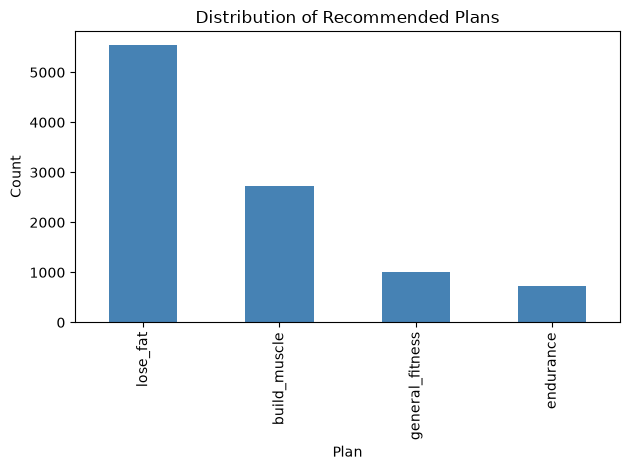

In [104]:
df_syn["recommended_plan"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Recommended Plans")
plt.xlabel("Plan")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Note on Class Imbalance
The dataset is imbalanced — lose_fat dominates at 55%. This is somewhat realistic 
(more people want to lose fat than train for endurance) but may cause the model to 
underperform on minority classes. We'll evaluate per-class performance in the classification 
report and could address this with class weighting or oversampling (SMOTE) in a future iteration.

In [105]:
from sklearn.model_selection import train_test_split

X = df_syn.drop(columns=["recommended_plan"])
y = df_syn["recommended_plan"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 8)
Test set: (2000, 8)


In [106]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train_encoded)

print("Model trained successfully")
print(f"Classes: {le.classes_}")

Model trained successfully
Classes: ['build_muscle' 'endurance' 'general_fitness' 'lose_fat']


In [107]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print("\n", classification_report(y_test_encoded, y_pred, target_names=le.classes_))

Accuracy: 99.90%

                  precision    recall  f1-score   support

   build_muscle       1.00      1.00      1.00       534
      endurance       1.00      1.00      1.00       148
general_fitness       1.00      1.00      1.00       213
       lose_fat       1.00      1.00      1.00      1105

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000



In [108]:
import random

def assign_recommended_plan_noisy(row):
    plan = assign_recommended_plan(row)
    
    # 15% chance of randomly flipping to a different plan
    if random.random() < 0.25:
        options = ["lose_fat", "build_muscle", "endurance", "general_fitness"]
        options.remove(plan)
        return random.choice(options)
    
    return plan

random.seed(42)
df_syn["recommended_plan"] = df_syn.apply(assign_recommended_plan_noisy, axis=1)
df_syn["recommended_plan"].value_counts()

recommended_plan
lose_fat           4517
build_muscle       2626
general_fitness    1513
endurance          1344
Name: count, dtype: int64

In [110]:
import joblib

joblib.dump(model, "goal_recommender.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model saved successfully")

Model saved successfully


##Limitations
BMI is a flawed metric, it can't distinguish between muscle mass and fat mass and can give the same BMI for a 200 lb bodybuilder and a 200 lb sedentary person. This is a limitation of the current model.